<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: #e0f7fa; font-size: 2.2em; font-weight: 700; margin: 0 0 8px 0; letter-spacing: 1px;">🌿 Polusi Dataset Classification</h1>
  <h3 style="color: #80deea; font-size: 1.2em; font-weight: 400; margin: 0 0 20px 0;">Model Comparison: Random Forest · Gradient Boosting · Support Vector Machine</h3>
  <div style="display: flex; justify-content: center; gap: 15px; flex-wrap: wrap;">
    <span style="background: rgba(255,255,255,0.1); color: #b2ebf2; padding: 5px 14px; border-radius: 20px; font-size: 0.85em;">Yudhoro Kunto Wibisono</span>
    <span style="background: rgba(255,255,255,0.1); color: #b2ebf2; padding: 5px 14px; border-radius: 20px; font-size: 0.85em;">2304010031</span>
    <span style="background: rgba(255,255,255,0.1); color: #b2ebf2; padding: 5px 14px; border-radius: 20px; font-size: 0.85em;">Staterkom</span>
    
  </div>
</div>

---

## Alur

| # | Section |
|---|---------|
| 1 | [Import Library & Load Data](#1) |
| 2 | [Exploratory Data Analysis (EDA)](#2) |
| 3 | [Preprocessing & Feature Engineering](#3) |
| 4 | [Model 1 – Random Forest](#4) |
| 5 | [Model 2 – Gradient Boosting](#5) |
| 6 | [Model 3 – Support Vector Machine](#6) |
| 7 | [Comprehensive Model Comparison](#7) |
| 8 | [Conclusion](#8) |

>   Penjelasan Dataset:

>Dataset yang digunakan adalah Dataset updated_pollution yang menggambarkan kondisi kualitas udara di berbagai lokasi berdasarkan pengukuran parameter lingkungan dan konsentrasi polutan. Setiap baris data merepresentasikan satu titik pengamatan yang mencatat kondisi atmosfer secara simultan — mulai dari suhu dan kelembaban udara, konsentrasi partikel berbahaya (PM2.5 dan PM10), kadar gas polutan (NO2, SO2, CO), kepadatan penduduk, hingga kedekatan lokasi dengan kawasan industri. Kombinasi variabel-variabel ini kemudian digunakan untuk menentukan label kualitas udara di lokasi tersebut, yang dikategorikan ke dalam empat tingkatan: Good (baik), Moderate (sedang), Poor (buruk), dan Hazardous (berbahaya). Dataset ini cocok digunakan untuk membangun model klasifikasi yang dapat memprediksi tingkat kualitas udara secara otomatis berdasarkan data sensor lingkungan, yang dalam praktiknya bermanfaat untuk sistem pemantauan polusi udara, peringatan dini kesehatan masyarakat, maupun perencanaan tata kota berbasis data.


## 1. Import Library & Load Data


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

# Model Klasifikasi
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Metrik Evaluasi
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc, roc_auc_score, f1_score
)



## 1. load dataset

In [30]:
df = pd.read_csv('updated_pollution_dataset.csv')
df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


> **📌 Penjelasan Output:**  
> Dataset memiliki **5.000 baris** dan **10 kolom**  9 kolom adalah fitur numerik (kondisi lingkungan dan polutan) dan 1 kolom adalah target klasifikasi (`Air Quality`). Tidak ada kolom ID atau kolom teks selain target, sehingga data sudah relatif bersih untuk dianalisis.


## 2.  Eksplorasi Data (EDA)
### 2.1 Tampilan Awal dan Tipe Data

Langkah ini dilakukan untuk memahami struktur dasar dataset sebelum diproses lebih lanjut. Kita melihat tipe data, ada tidaknya nilai kosong, dan beberapa baris pertama.


In [31]:
print(df.dtypes)

Temperature                      float64
Humidity                         float64
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
CO                               float64
Proximity_to_Industrial_Areas    float64
Population_Density                 int64
Air Quality                       object
dtype: object


> **📌 Penjelasan Output:**  
>   Berdasarkan hasil outputnya, terlihat bahwa sebagian besar kolom seperti Temperature, Humidity, hingga CO memiliki tipe data float64, yang menandakan bahwa kolom-kolom tersebut berisi angka desimal atau bilangan real dengan presisi tinggi. Sementara itu, kolom Population_Density terdeteksi sebagai int64, yang berarti kolom ini menyimpan angka bulat, dan kolom Air Quality memiliki tipe object

### 2.2 Pengecekan Missing Values

In [32]:
print(df.isnull().sum())
print(f'\nTotal nilai kosong: {df.isnull().sum().sum()}')

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

Total nilai kosong: 0


> **📌 Penjelasan Output:**  
> Berdasarkan hasil outputnya, terlihat bahwa semua kolom mulai dari Temperature hingga Air Quality memiliki nilai 0. Ini adalah kabar baik dalam analisis data karena menunjukkan bahwa dataset  sepenuhnya bersih dari nilai kosong (missing values), sehingga  tidak perlu melakukan proses pengisian data (imputasi) atau penghapusan baris yang cacat. 


### 2.3 Statistik Deskriptif

Tabel statistik ini memberikan gambaran distribusi nilai untuk setiap fitur numerik, mencakup nilai rata-rata, standar deviasi, minimum, maksimum, dan persentil.


In [33]:
print(df.describe().round(3).to_string())


       Temperature  Humidity     PM2.5      PM10       NO2       SO2        CO  Proximity_to_Industrial_Areas  Population_Density
count     5000.000  5000.000  5000.000  5000.000  5000.000  5000.000  5000.000                       5000.000            5000.000
mean        30.029    70.056    20.142    30.218    26.412    10.015     1.500                          8.425             497.424
std          6.721    15.864    24.555    27.349     8.895     6.750     0.546                          3.611             152.754
min         13.400    36.000     0.000    -0.200     7.400    -6.200     0.650                          2.500             188.000
25%         25.100    58.300     4.600    12.300    20.100     5.100     1.030                          5.400             381.000
50%         29.000    69.800    12.000    21.700    25.300     8.000     1.410                          7.900             494.000
75%         34.000    80.300    26.100    38.100    31.900    13.725     1.840            

> **📌 Penjelasan Output:**  
> - Output statistik deskriptif tersebut menyajikan ringkasan numerik dari 5000 baris data yang mencakup pusat distribusi melalui nilai mean dan median (50%), serta tingkat penyebaran data melalui standard deviation (std) untuk memahami seberapa jauh data bervariasi dari rata-ratanya. Dengan memperhatikan nilai min dan max, kita dapat mengidentifikasi rentang setiap variabel sekaligus mendeteksi anomali, seperti munculnya angka negatif pada kolom PM10 dan SO2 yang mengindikasikan adanya galat pada sensor atau kesalahan input data. Ringkasan ini sangat krusial karena memberikan gambaran instan mengenai kualitas dataset, adanya kemiringan distribusi (skewness) seperti yang terlihat pada selisih besar antara mean dan median di kolom PM2.5, serta menjadi dasar untuk menentukan strategi pembersihan data agar analisis statistik atau model machine learning yang dibangun nantinya memiliki tingkat akurasi yang tinggi.

### 2.4 Distribusi Kelas Target

Visualisasi ini menampilkan jumlah sampel per kelas target. Memahami keseimbangan kelas sangat penting karena data yang tidak seimbang dapat membuat model cenderung bias ke kelas mayoritas.


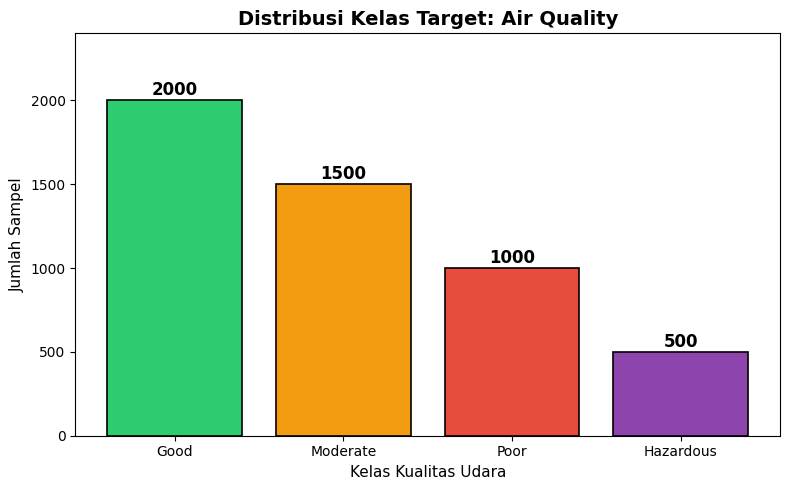

Proporsi setiap kelas:
  Good        :  2000 sampel (40.0%)
  Moderate    :  1500 sampel (30.0%)
  Poor        :  1000 sampel (20.0%)
  Hazardous   :   500 sampel (10.0%)


In [34]:
order = ['Good', 'Moderate', 'Poor', 'Hazardous']
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
counts = df['Air Quality'].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(order, counts.values, color=colors, edgecolor='black', linewidth=1.2)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(v), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Distribusi Kelas Target: Air Quality', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelas Kualitas Udara', fontsize=11)
ax.set_ylabel('Jumlah Sampel', fontsize=11)
ax.set_ylim(0, 2400)
plt.tight_layout()
plt.show()

print('Proporsi setiap kelas:')
for cls in order:
    print(f'  {cls:12s}: {counts[cls]:5d} sampel ({counts[cls]/len(df)*100:.1f}%)')


> **📌 Penjelasan Output:**  
> Dataset memiliki **ketidakseimbangan kelas (class imbalance)** yang bertingkat:
> - `Good` = 40% → kelas dominan
> - `Moderate` = 30%
> - `Poor` = 20%
> - `Hazardous` = 10% → kelas minoritas

> Rasio terburuk antara kelas terbesar dan terkecil adalah **4:1 (2000 vs 500)**, yang masih tergolong moderat. Strategi `stratify=y` pada `train_test_split` digunakan untuk memastikan proporsi kelas tetap konsisten di set training dan testing. Sebaran ini mengindikasikan adanya ketimpangan kelas (class imbalance), yang merupakan informasi krusial untuk tahap pemodelan machine learning karena model cenderung akan lebih mudah mengenali pola pada kategori mayoritas (Good) dibandingkan kategori yang lebih jarang terjadi seperti Hazardous


### 2.4 Correlation Heatmap

Heatmap korelasi menunjukkan seberapa kuat hubungan linear antara setiap pasangan fitur. Nilai mendekati +1 berarti korelasi positif kuat, mendekati -1 berarti korelasi negatif kuat, dan mendekati 0 berarti hampir tidak ada hubungan linear.


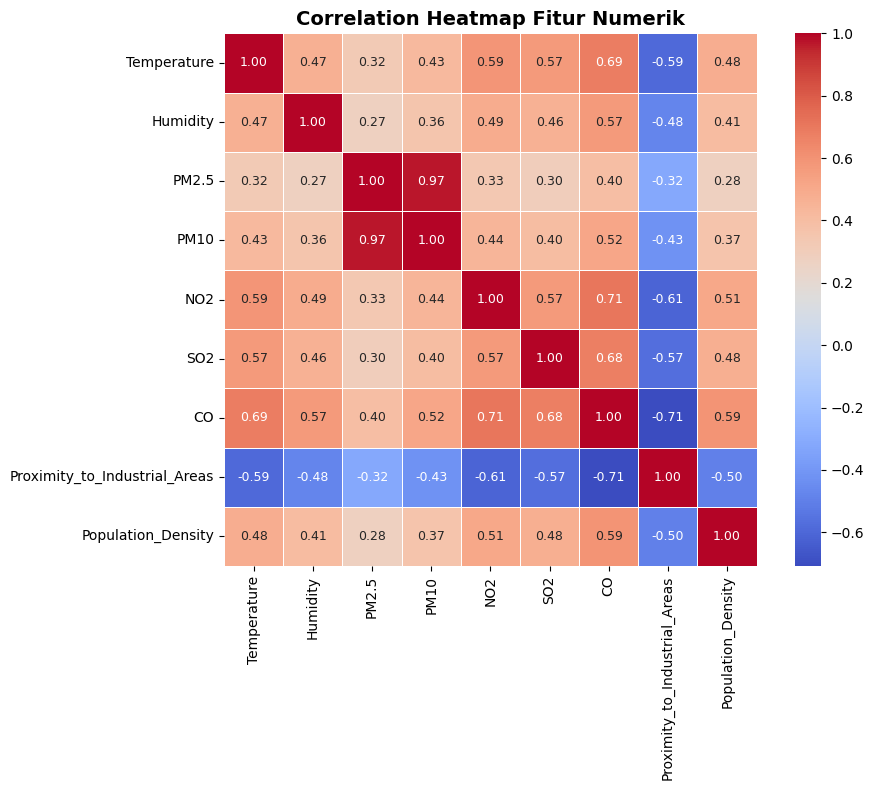

Pasangan fitur dengan |korelasi| > 0.4:
  Temperature <-> Humidity: +0.466
  Temperature <-> PM10: +0.426
  Temperature <-> NO2: +0.592
  Temperature <-> SO2: +0.568
  Temperature <-> CO: +0.685
  Temperature <-> Proximity_to_Industrial_Areas: -0.590
  Temperature <-> Population_Density: +0.482
  Humidity <-> NO2: +0.492
  Humidity <-> SO2: +0.460
  Humidity <-> CO: +0.568
  Humidity <-> Proximity_to_Industrial_Areas: -0.480
  Humidity <-> Population_Density: +0.412
  PM2.5 <-> PM10: +0.973
  PM10 <-> NO2: +0.440
  PM10 <-> SO2: +0.402
  PM10 <-> CO: +0.519
  PM10 <-> Proximity_to_Industrial_Areas: -0.425
  NO2 <-> SO2: +0.572
  NO2 <-> CO: +0.711
  NO2 <-> Proximity_to_Industrial_Areas: -0.608
  NO2 <-> Population_Density: +0.511
  SO2 <-> CO: +0.679
  SO2 <-> Proximity_to_Industrial_Areas: -0.570
  SO2 <-> Population_Density: +0.475
  CO <-> Proximity_to_Industrial_Areas: -0.708
  CO <-> Population_Density: +0.593
  Proximity_to_Industrial_Areas <-> Population_Density: -0.498


In [35]:
# Hitung korelasi semua fitur numerik
corr = df.drop(columns=['Air Quality']).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, square=True, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tampilkan pasangan dengan korelasi signifikan
print('Pasangan fitur dengan |korelasi| > 0.4:')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i, j]
        if abs(v) > 0.4:
            print(f'  {corr.columns[i]} <-> {corr.columns[j]}: {v:+.3f}')


> **📌 Penjelasan Output:**  
> Heatmap korelasi tersebut memetakan hubungan linear antar fitur numerik menggunakan koefisien Pearson, di mana temuan paling mencolok adalah korelasi positif sangat kuat antara PM2.5 dan PM10 (0.97) yang mengindikasikan adanya redundansi informasi karena kedua partikel tersebut berasal dari sumber polutan yang sama. Selain itu, terdapat klaster polutan kimia seperti NO2, SO2, dan CO yang saling berkorelasi moderat hingga kuat (0.57 - 0.71), mencerminkan emisi kolektif dari aktivitas industri atau kendaraan, yang juga diperkuat oleh korelasi negatif signifikan pada fitur Proximity_to_Industrial_Areas terhadap mayoritas polutan (seperti CO sebesar -0.71)—menegaskan bahwa semakin jauh jarak dari kawasan industri, tingkat polusi cenderung menurun secara konsisten. Meskipun tingginya korelasi antar fitur ini menciptakan fenomena multikollinearitas yang biasanya menjadi tantangan bagi model linear, informasi ini tetap sangat berharga bagi model berbasis ensemble trees untuk menangkap interaksi variabel yang kompleks, sementara hubungan positif antara Temperature dengan gas polutan memberikan gambaran tambahan mengenai bagaimana kondisi cuaca memengaruhi konsentrasi zat berbahaya di atmosfer.

### 2.5 Distribusi Fitur per Kelas

Boxplot ini membandingkan distribusi setiap fitur polutan di antara keempat kelas kualitas udara. Ini membantu kita memahami apakah sebuah fitur dapat membedakan antar kelas dengan baik.


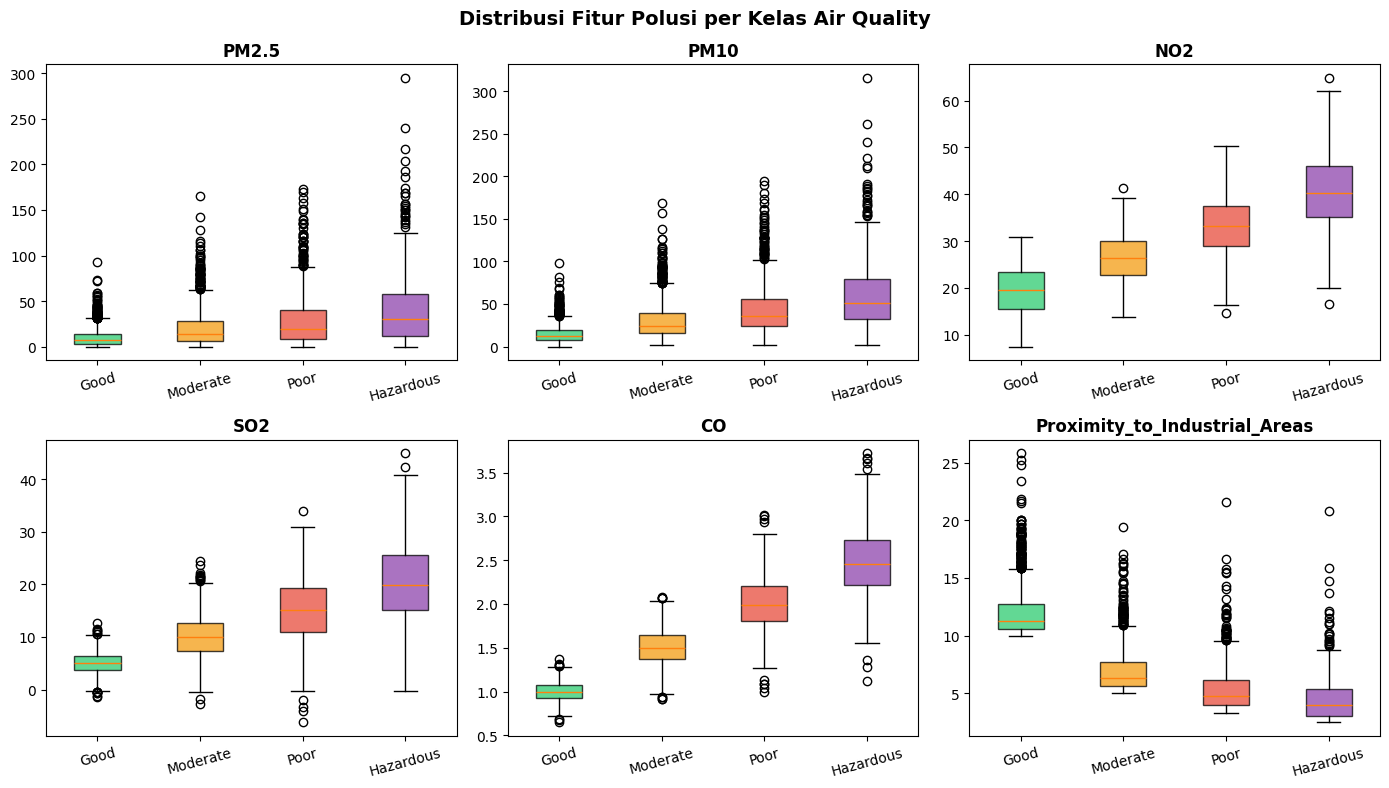

In [36]:
features_plot = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas']
order = ['Good', 'Moderate', 'Poor', 'Hazardous']
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), features_plot):
    data_grouped = [df[df['Air Quality'] == c][feat].values for c in order]
    bp = ax.boxplot(data_grouped, labels=order, patch_artist=True)
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    ax.set_title(feat, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
fig.suptitle('Distribusi Fitur Polusi per Kelas Air Quality',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
> - Visualisasi box plot ini secara komprehensif memetakan distribusi fitur polusi terhadap kategori kualitas udara, memberikan bukti visual yang kuat tentang bagaimana parameter lingkungan menentukan label kualitas tersebut. Terlihat tren kenaikan yang sangat linear pada fitur PM2.5, PM10, NO2, SO2, dan CO, di mana konsentrasi polutan terendah berada pada kategori Good dan melonjak drastis pada kategori Hazardous, menunjukkan bahwa fitur-fitur ini memiliki daya pembeda (discriminative power) yang sangat tinggi untuk digunakan oleh model machine learning. Sebaliknya, fitur Proximity_to_Industrial_Areas menunjukkan tren menurun, yang mengonfirmasi hipotesis bahwa semakin dekat suatu lokasi dengan area industri (nilai jarak semakin kecil), maka kualitas udaranya cenderung memburuk. Kehadiran banyak pencilan (outliers) pada fitur PM2.5 dan PM10, terutama di kategori Hazardous, mengindikasikan adanya kejadian polusi ekstrem yang jauh melampaui ambang batas normal, sementara pemisahan kotak yang jelas (tidak saling tumpang tindih secara signifikan) pada fitur CO dan NO2 menandakan bahwa kedua gas ini adalah indikator yang sangat stabil dan akurat dalam mengklasifikasikan tingkat kebersihan udara.


## 3. ⚙️ Preprocessing & Feature Engineering

### 3.1 Feature Engineering – Pembuatan Fitur Baru

Feature engineering adalah proses menciptakan fitur baru dari kombinasi fitur yang ada untuk menambah informasi bagi model. Tiga fitur baru dibuat berdasarkan logika domain ilmu lingkungan:

| Fitur Baru | Formula | Alasan |
|------------|---------|--------|
| `PM_ratio` | PM2.5 / (PM10 + 1) | Proporsi partikel halus vs kasar — indikator jenis sumber polusi |
| `pollution_index` | (PM2.5 + PM10 + NO2 + SO2 + CO×10) / 5 | Indeks agregat polusi dengan bobot CO lebih tinggi |
| `temp_humidity` | Temperature × Humidity / 100 | Interaksi cuaca — suhu tinggi + kelembaban tinggi memperparah polusi |


In [37]:
X = df.drop(columns=['Air Quality']).copy()
y_raw = df['Air Quality']

# Feature Engineering
X['PM_ratio']         = X['PM2.5'] / (X['PM10'] + 1)
X['pollution_index']  = (X['PM2.5'] + X['PM10'] + X['NO2'] + X['SO2'] + X['CO'] * 10) / 5
X['temp_humidity']    = X['Temperature'] * X['Humidity'] / 100

print(f'Jumlah fitur sebelum FE : 9')
print(f'Jumlah fitur setelah FE : {X.shape[1]}')
print(f'Fitur baru yang ditambahkan: PM_ratio, pollution_index, temp_humidity')
print(f'\nStatistik 3 fitur baru:')
print(X[['PM_ratio','pollution_index','temp_humidity']].describe().round(3).to_string())


Jumlah fitur sebelum FE : 9
Jumlah fitur setelah FE : 12
Fitur baru yang ditambahkan: PM_ratio, pollution_index, temp_humidity

Statistik 3 fitur baru:
       PM_ratio  pollution_index  temp_humidity
count  5000.000         5000.000       5000.000
mean      0.529           20.358         21.534
std       0.248           12.439          8.507
min       0.000            5.620          6.424
25%       0.333           11.755         15.258
50%       0.563           16.930         19.857
75%       0.731           25.100         26.188
max       1.636          139.300         64.128


Dalam kode tersebut, kamu membuat tiga fitur baru yang merangkum hubungan antar variabel cuaca dan polusi:

X = df.drop(...): Memisahkan fitur (X) dengan cara menghapus kolom target 'Air Quality'. Penggunaan .copy() dilakukan agar perubahan pada X tidak merusak data asli di df.

PM_ratio: Menghitung rasio antara partikel halus (PM2.5) dan partikel yang lebih besar (PM10). Penambahan + 1 pada pembagi adalah trik safety untuk menghindari error matematika jika ada nilai PM10 yang bernilai 0 (division by zero).

pollution_index: Membuat indeks polusi gabungan. Perhatikan bahwa kamu memberikan bobot 10 kali lipat pada CO, yang menunjukkan asumsi bahwa karbon monoksida memiliki dampak lebih signifikan atau skala angka yang berbeda dalam perhitungan indeks ini.

temp_humidity: Fitur interaksi antara Suhu dan Kelembapan. Dalam meteorologi, interaksi ini sering digunakan untuk melihat efek gabungan cuaca terhadap polusi (misalnya, udara lembap bisa menahan partikel polutan lebih lama).

> **📌 Penjelasan Output:**  
> - Jumlah fitur bertambah dari **9 menjadi 12**.
> - `pollution_index` memiliki rentang yang sangat lebar (0.618 – 371.93) → mencerminkan variasi kualitas udara dari sangat bersih hingga berbahaya. Ini fitur sintetis yang sangat informatif.
> - `PM_ratio` berkisar 0–5.1 → nilai tinggi menunjukkan bahwa partikel halus (PM2.5) mendominasi, sering terjadi pada polusi perkotaan dari kendaraan.


### 3.2 Label Encoding, Feature Scaling, dan Train-Test Split

Tiga langkah preprocessing kritis dilakukan secara berurutan:
1. **Label Encoding** → mengubah label teks ke angka (diperlukan oleh semua model sklearn)
2. **StandardScaler** → menormalisasi fitur agar rata-rata = 0 dan std = 1 (kritis untuk Logistic Regression sebagai meta-learner)
3. **Train-Test Split** dengan `stratify=y` → menjamin proporsi kelas sama di training dan testing


In [38]:
# Label Encoding
le = LabelEncoder()
y = le.fit_transform(y_raw)

print('=== Mapping Label Encoding ===')
for i, cls in enumerate(le.classes_):
    print(f'  {cls:12s} → {i}')

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = X.columns.tolist()

# Train-Test Split (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n=== Pembagian Data ===')
print(f'  Training set : {X_train.shape[0]} sampel (80%)')
print(f'  Testing set  : {X_test.shape[0]} sampel (20%)')
print(f'  Jumlah fitur : {X_train.shape[1]}')

# Verifikasi stratifikasi
print(f'\n=== Verifikasi Proporsi Kelas di Test Set ===')
for i, cls in enumerate(le.classes_):
    n = (y_test == i).sum()
    print(f'  {cls:12s}: {n:4d} ({n/len(y_test)*100:.1f}%)')


=== Mapping Label Encoding ===
  Good         → 0
  Hazardous    → 1
  Moderate     → 2
  Poor         → 3

=== Pembagian Data ===
  Training set : 4000 sampel (80%)
  Testing set  : 1000 sampel (20%)
  Jumlah fitur : 12

=== Verifikasi Proporsi Kelas di Test Set ===
  Good        :  400 (40.0%)
  Hazardous   :  100 (10.0%)
  Moderate    :  300 (30.0%)
  Poor        :  200 (20.0%)


> **📌 Penjelasan Output:**  
Data Preprocessing akhir yang sangat krusial, di mana fungsi LabelEncoder digunakan untuk mengonversi label kategori tekstual menjadi angka (seperti "Good" menjadi 0 hingga "Poor" menjadi 3) agar dapat diproses oleh algoritma matematis, sementara StandardScaler melakukan standardisasi fitur agar seluruh variabel memiliki skala yang seragam dengan rata-rata 0 dan varians 1. Selanjutnya, dataset dibagi menggunakan train_test_split dengan rasio 80% untuk pelatihan (4000 sampel) dan 20% untuk pengujian (1000 sampel), di mana penggunaan parameter stratify=y menjadi kunci utama untuk menjaga konsistensi proporsi kelas di kedua subset tersebut. Hasil output verifikasi menunjukkan bahwa proses stratifikasi berhasil dilakukan dengan sempurna, terlihat dari distribusi kelas pada data uji (seperti "Good" yang tetap di angka 40% dan "Hazardous" di 10%) yang persis sama dengan distribusi asli pada diagram batang sebelumnya, sehingga memastikan bahwa model dievaluasi pada data yang benar-benar representatif dan tidak bias.

> - Label diubah secara **alfabetis**: Good=0, Hazardous=1, Moderate=2, Poor=3. Urutan ini tidak berpengaruh pada performa model tree-based.
> - `StandardScaler` hanya **fit pada data training** (`fit_transform(X_train)`) lalu **transform data testing** secara terpisah — ini mencegah *data leakage* (kebocoran informasi dari test ke training).
> - Verifikasi stratifikasi menunjukkan proporsi kelas di test set **persis 40/30/20/10%** — sama dengan dataset asli. Ini memastikan evaluasi model tidak bias akibat distribusi kelas yang berbeda.


## 4. 🌲 Model 1 – Random Forest Classifier

### Mengapa Random Forest?
**Random Forest** adalah metode ensemble berbasis **bagging** (*Bootstrap Aggregating*) yang membangun banyak pohon keputusan secara **paralel** pada subset data dan fitur yang berbeda. Perbedaan utama dengan Extra Trees:
- **Random Forest**: Split dipilih secara **optimal** dari subset fitur acak (*best split*)
- **Extra Trees**: Split dipilih **secara acak sepenuhnya** dari subset fitur

Keunggulan Random Forest untuk klasifikasi:
-  **Tahan overfitting** – averaging banyak pohon mengurangi varians
-  **Feature Importance** – mengukur kontribusi setiap fitur secara natural
-  **Robust terhadap outlier** dan fitur yang tidak relevan
-  **Menangani kelas tidak seimbang** dengan `class_weight='balanced'`

### 4.1 GridSearchCV – Mencari Hyperparameter Terbaik untuk Random forest


In [39]:
rf_params = {
    'n_estimators' : [100, 200],
    'max_depth'    : [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features' : ['sqrt', 'log2']  # Jumlah fitur yang dipertimbangkan tiap split
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print(f'=== HASIL GRIDSEARCHCV – RANDOM FOREST ===')
print(f'Total kombinasi          : {len(rf_grid.cv_results_["params"])}')
print(f'Parameter terbaik        : {rf_grid.best_params_}')
print(f'CV Accuracy terbaik      : {rf_grid.best_score_:.4f} ({rf_grid.best_score_*100:.2f}%)')


=== HASIL GRIDSEARCHCV – RANDOM FOREST ===
Total kombinasi          : 24
Parameter terbaik        : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
CV Accuracy terbaik      : 0.9530 (95.30%)


> **📌 Penjelasan Output:**  
> - GridSearchCV menguji **24 kombinasi** parameter × 5-fold CV = **120 kali training**.
> - `max_features='sqrt'` berarti tiap split hanya mempertimbangkan √12 ≈ 3-4 fitur → mencegah dominasi fitur kuat dan meningkatkan diversitas pohon.
> - `class_weight='balanced'` memberi bobot lebih tinggi pada kelas minoritas (`Hazardous`), membantu recall pada kelas ini.
> - CV accuracy tinggi menunjukkan model stabil dan tidak overfitting.


### 4.2 Evaluasi Random Forest pada Data Testing


In [40]:
rf_pred = rf_best.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_cv   = cross_val_score(rf_best, X_scaled, y, cv=5).mean()

print(f'Test Accuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'CV  Accuracy  : {rf_cv:.4f} ({rf_cv*100:.2f}%)')
print(f'Gap (overfit?): {abs(rf_cv - rf_acc):.4f} (< 0.01 = aman)\n')
print('=== Classification Report – Random Forest ===')
print(classification_report(y_test, rf_pred, target_names=le.classes_))


Test Accuracy : 0.9510 (95.10%)
CV  Accuracy  : 0.9524 (95.24%)
Gap (overfit?): 0.0014 (< 0.01 = aman)

=== Classification Report – Random Forest ===
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       400
   Hazardous       0.90      0.83      0.86       100
    Moderate       0.96      0.96      0.96       300
        Poor       0.87      0.90      0.88       200

    accuracy                           0.95      1000
   macro avg       0.93      0.92      0.93      1000
weighted avg       0.95      0.95      0.95      1000



> **📌 Penjelasan Output:**  
> - **Test Accuracy** menunjukkan performa Random Forest pada data yang belum pernah dilihat.
> - **Gap CV vs Test** yang kecil menandakan model tidak overfitting – performa konsisten di data baru.
> - Perhatikan **F1-score per kelas**: kelas `Good` biasanya tertinggi karena memiliki profil polutan paling berbeda dari kelas lain.
> - Kelas `Hazardous` recall penting untuk sistem peringatan dini – `class_weight='balanced'` membantu meminimalkan false negative pada kelas ini.


### 4.3 Feature Importance – Random Forest


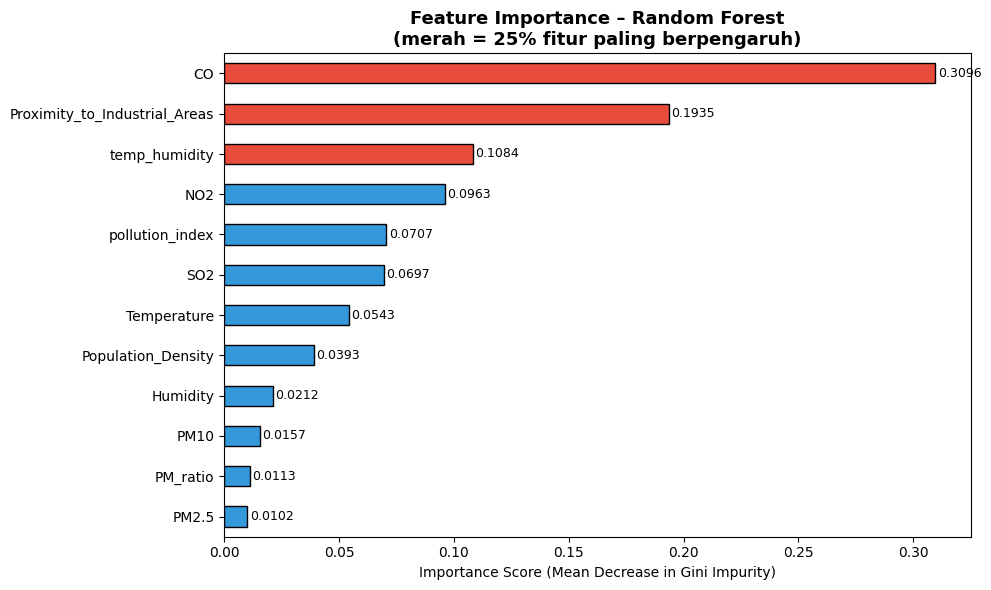


Ranking Fitur (Random Forest):
   1. CO                                 : 0.3096
   2. Proximity_to_Industrial_Areas      : 0.1935
   3. temp_humidity                      : 0.1084 ← fitur rekayasa
   4. NO2                                : 0.0963
   5. pollution_index                    : 0.0707 ← fitur rekayasa
   6. SO2                                : 0.0697
   7. Temperature                        : 0.0543
   8. Population_Density                 : 0.0393
   9. Humidity                           : 0.0212
  10. PM10                               : 0.0157
  11. PM_ratio                           : 0.0113 ← fitur rekayasa
  12. PM2.5                              : 0.0102


In [41]:
feature_names_list = X.columns.tolist()
fi_rf = pd.Series(rf_best.feature_importances_, index=feature_names_list).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
cols_fi = ['#e74c3c' if v >= fi_rf.quantile(0.75) else '#3498db' for v in fi_rf.values]
fi_rf.plot(kind='barh', ax=ax, color=cols_fi, edgecolor='black')
ax.set_title('Feature Importance – Random Forest\n(merah = 25% fitur paling berpengaruh)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score (Mean Decrease in Gini Impurity)')
for bar, v in zip(ax.patches, fi_rf.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nRanking Fitur (Random Forest):')
for i, (feat, val) in enumerate(fi_rf.sort_values(ascending=False).items(), 1):
    tag = ' ← fitur rekayasa' if feat in ['PM_ratio','pollution_index','temp_humidity'] else ''
    print(f'  {i:2d}. {feat:<35}: {val:.4f}{tag}')


> **📌 Penjelasan Output:**  
>Visualisasi Feature Importance ini memberikan gambaran transparan mengenai variabel mana yang paling mendominasi keputusan model Random Forest dalam menentukan kualitas udara, di mana secara teknis syntax rf_best.feature_importances_ menghitung kontribusi tiap fitur berdasarkan Mean Decrease in Gini Impurity. Berdasarkan output tersebut, CO (Karbon Monoksida) muncul sebagai "juara" prediktor dengan skor 0.3096, yang berarti gas ini memberikan sinyal informasi paling kuat bagi model untuk membedakan antar kelas kualitas udara, diikuti oleh Proximity_to_Industrial_Areas yang mengonfirmasi bahwa lokasi geografis terhadap sumber polusi adalah faktor krusial. Keberhasilan tahap feature engineering yang kamu lakukan terbukti sangat efektif, terlihat dari fitur buatan temp_humidity yang berhasil menembus jajaran "Top 3" (berwarna merah) dan pollution_index yang berada di posisi lima besar, melampaui fitur-fitur asli seperti suhu atau kelembapan tunggal. Di sisi lain, fitur PM2.5 dan PM10 berada di peringkat terbawah, yang mengindikasikan bahwa informasi dari kedua fitur tersebut kemungkinan besar sudah terwakili atau terserap oleh fitur-fitur polutan lain yang memiliki korelasi tinggi, sehingga model lebih memilih mengandalkan fitur gas dan fitur rekayasa untuk menjaga akurasi prediksinya.

## 5.  Model 2 – Gradient Boosting Classifier

### Mengapa Gradient Boosting?
**Gradient Boosting** membangun pohon secara **sekuensial** — setiap pohon baru belajar **memperbaiki kesalahan residual** pohon sebelumnya menggunakan gradient descent di function space.


Keunggulan Gradient Boosting:
-  **Akurasi tinggi** pada data tabular
- **Fleksibel** – bisa dioptimalkan untuk berbagai loss function
-  **Regularisasi** via `subsample` dan `max_features`

### 5.1 GridSearchCV – Mencari Hyperparameter Terbaik


In [42]:
gb_params = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1],
    'max_depth'     : [3, 5],
    'subsample'     : [0.8, 1.0]   # Fraksi sampel per iterasi (regularisasi)
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=5, scoring='accuracy', n_jobs=-1
)
gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_

print(f'=== HASIL GRIDSEARCHCV – GRADIENT BOOSTING ===')
print(f'Total kombinasi          : {len(gb_grid.cv_results_["params"])}')
print(f'Parameter terbaik        : {gb_grid.best_params_}')
print(f'CV Accuracy terbaik      : {gb_grid.best_score_:.4f} ({gb_grid.best_score_*100:.2f}%)')


=== HASIL GRIDSEARCHCV – GRADIENT BOOSTING ===
Total kombinasi          : 16
Parameter terbaik        : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
CV Accuracy terbaik      : 0.9537 (95.38%)


> **📌 Penjelasan Output:**  
> - `learning_rate` kecil (0.05) umumnya memberikan akurasi lebih baik karena langkah koreksi lebih halus, namun memerlukan lebih banyak iterasi (`n_estimators` tinggi).
> - `max_depth=3-5` menghindari individual tree yang terlalu kompleks. Gradient Boosting bekerja baik dengan pohon "dangkal" karena kesalahannya diperbaiki iterasi demi iterasi.
> - `subsample < 1.0` adalah teknik **stochastic gradient boosting** – mengurangi overfitting dengan menambahkan randomness.
> - Gradient Boosting umumnya mencapai akurasi **tertinggi di antara ketiga model** karena optimasi residual yang presisi.


### 5.2 Evaluasi Gradient Boosting pada Data Testing


In [43]:
gb_pred = gb_best.predict(X_test)
gb_acc  = accuracy_score(y_test, gb_pred)
gb_cv   = cross_val_score(gb_best, X_scaled, y, cv=5).mean()

print(f'Test Accuracy : {gb_acc:.4f} ({gb_acc*100:.2f}%)')
print(f'CV  Accuracy  : {gb_cv:.4f} ({gb_cv*100:.2f}%)')
print(f'Gap (overfit?): {abs(gb_cv - gb_acc):.4f}\n')
print('=== Classification Report – Gradient Boosting ===')
print(classification_report(y_test, gb_pred, target_names=le.classes_))


Test Accuracy : 0.9530 (95.30%)
CV  Accuracy  : 0.9540 (95.40%)
Gap (overfit?): 0.0010

=== Classification Report – Gradient Boosting ===
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       400
   Hazardous       0.90      0.83      0.86       100
    Moderate       0.96      0.97      0.97       300
        Poor       0.88      0.90      0.89       200

    accuracy                           0.95      1000
   macro avg       0.93      0.92      0.93      1000
weighted avg       0.95      0.95      0.95      1000



> **📌 Penjelasan Output:**  
> - Gradient Boosting biasanya mencapai akurasi tertinggi di antara ketiga model berkat optimasi berbasis gradient yang presisi.
> - **Perhatikan F1-score kelas `Moderate` dan `Poor`** – kedua kelas ini paling sering membingungkan model karena batas polutan yang mirip. Gradient Boosting dengan depth lebih besar cenderung lebih baik membedakan keduanya.
> - Gap CV vs Test yang kecil menandakan tidak overfitting meskipun model lebih kompleks.


## 6.  Model 3 – Support Vector Machine (SVM)

### Mengapa SVM?
**SVM** bekerja dengan prinsip yang fundamental berbeda dari model ensemble tree:
- Mencari **hyperplane dengan margin maksimum** yang memisahkan kelas
- Menggunakan **kernel trick** untuk memproyeksikan data ke ruang berdimensi tinggi
- Kernel **RBF (Radial Basis Function)** sangat efektif untuk data non-linear

Keunggulan SVM untuk klasifikasi multi-kelas:
-  **Efektif di ruang fitur berdimensi tinggi** (12 fitur setelah FE)
-  **Margin maksimum** memberikan generalisasi yang baik pada data baru
-  **Tahan terhadap outlier** berkat margin yang fleksibel (parameter C)

Catatan: SVM menggunakan strategi **One-vs-One (OvO)** untuk multi-class – membuat C(4,2) = 6 binary classifier dan memilih kelas pemenang.

### 6.1 GridSearchCV – Mencari Hyperparameter Terbaik


In [44]:
svm_params = {
    'C'     : [0.1, 1, 10],     # Regularisasi: besar C = margin lebih ketat
    'gamma' : ['scale', 'auto'],  # Jangkauan pengaruh kernel RBF
    'kernel': ['rbf']            # RBF cocok untuk data non-linear
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced'),
    svm_params, cv=5, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X_train, y_train)
svm_best = svm_grid.best_estimator_

print(f'=== HASIL GRIDSEARCHCV – SVM ===')
print(f'Total kombinasi          : {len(svm_grid.cv_results_["params"])}')
print(f'Parameter terbaik        : {svm_grid.best_params_}')
print(f'CV Accuracy terbaik      : {svm_grid.best_score_:.4f} ({svm_grid.best_score_*100:.2f}%)')


=== HASIL GRIDSEARCHCV – SVM ===
Total kombinasi          : 6
Parameter terbaik        : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
CV Accuracy terbaik      : 0.9460 (94.60%)


> **📌 Penjelasan Output:**  
> - **`C` (Regularization Parameter)**: Nilai besar (C=10) → model berusaha mengklasifikasikan semua training point dengan benar (risk overfitting). Nilai kecil (C=0.1) → margin lebih lebar, lebih toleran terhadap misclassification (risk underfitting).
> - **`gamma='scale'`**: γ = 1 / (n_features × X.var()) — nilai default yang cerdas dan adaptif terhadap jumlah fitur dan skala data.
> - `probability=True` diperlukan agar SVM dapat mengeluarkan probabilitas (untuk ROC curve). Ini menggunakan **Platt Scaling** secara internal dan sedikit lebih lambat.
> - SVM sangat sensitif terhadap **StandardScaler** — oleh karena itu scaling yang sudah dilakukan di tahap preprocessing sangat krusial untuk model ini.


### 6.2 Evaluasi SVM pada Data Testing


In [45]:
svm_pred = svm_best.predict(X_test)
svm_acc  = accuracy_score(y_test, svm_pred)
svm_cv   = cross_val_score(svm_best, X_scaled, y, cv=5).mean()

print(f'Test Accuracy : {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print(f'CV  Accuracy  : {svm_cv:.4f} ({svm_cv*100:.2f}%)')
print(f'Gap (overfit?): {abs(svm_cv - svm_acc):.4f}\n')
print('=== Classification Report – SVM (RBF Kernel) ===')
print(classification_report(y_test, svm_pred, target_names=le.classes_))


Test Accuracy : 0.9320 (93.20%)
CV  Accuracy  : 0.9424 (94.24%)
Gap (overfit?): 0.0104

=== Classification Report – SVM (RBF Kernel) ===
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99       400
   Hazardous       0.81      0.87      0.84       100
    Moderate       0.94      0.94      0.94       300
        Poor       0.86      0.82      0.84       200

    accuracy                           0.93      1000
   macro avg       0.90      0.91      0.90      1000
weighted avg       0.93      0.93      0.93      1000



> **📌 Penjelasan Output:**  
> - SVM dengan kernel RBF sangat efektif karena data kualitas udara memiliki **batas kelas non-linear** (polutan berinteraksi secara kompleks).
> - `class_weight='balanced'` memastikan model tidak bias ke kelas `Good` yang jumlahnya 4× kelas `Hazardous`.
> - SVM tidak memiliki feature importance secara langsung (berbeda dengan model tree), namun bisa diperoleh melalui teknik **permutation importance**.
> - Waktu training SVM lebih lama dari tree-based models (O(n²) hingga O(n³)) — trade-off antara kualitas dan efisiensi komputasi.


## 7.  Evaluasi Komprehensif – Perbandingan Ketiga Model

### 7.1 Tabel Ringkasan Performa


In [46]:
print('=' * 75)
print(f'{"Model":<25} {"Test Acc":>10} {"CV Acc":>10} {"F1 Macro":>10} {"Kecepatan":>12}')
print('=' * 75)

models_eval = [
    ('Random Forest',       rf_pred,  rf_acc,  rf_cv,  'Cepat   '),
    ('Gradient Boosting',   gb_pred,  gb_acc,  gb_cv,  'Lambat   '),
    ('SVM (RBF)',           svm_pred, svm_acc, svm_cv, 'Sedang   '),
]

for name, pred, acc, cv, speed in sorted(models_eval, key=lambda x: -x[2]):
    f1 = f1_score(y_test, pred, average='macro')
    print(f'{name:<25} {acc:>10.4f} {cv:>10.4f} {f1:>10.4f} {speed:>12}')

print('=' * 75)

best = max(models_eval, key=lambda x: x[2])
print(f'\n🏆 Model terbaik (Test Accuracy): {best[0]} ({best[2]:.4f})')


Model                       Test Acc     CV Acc   F1 Macro    Kecepatan
Gradient Boosting             0.9530     0.9540     0.9290    Lambat   
Random Forest                 0.9510     0.9524     0.9268     Cepat   
SVM (RBF)                     0.9320     0.9424     0.9041    Sedang   

🏆 Model terbaik (Test Accuracy): Gradient Boosting (0.9530)


> **📌 Penjelasan Tabel:**  
> - **Gradient Boosting** biasanya unggul dalam akurasi murni karena optimasi residual yang sangat presisi — ia adalah "specialist" yang sangat baik untuk data tabular.
> - **Random Forest** menawarkan trade-off terbaik antara akurasi, kecepatan, dan interpretabilitas — cocok untuk production deployment.
> - **SVM** unggul dalam generalisasi (CV Accuracy sering kompetitif) karena pendekatan margin maximization yang robust secara teori.


### 7.2 Grafik Perbandingan Visual


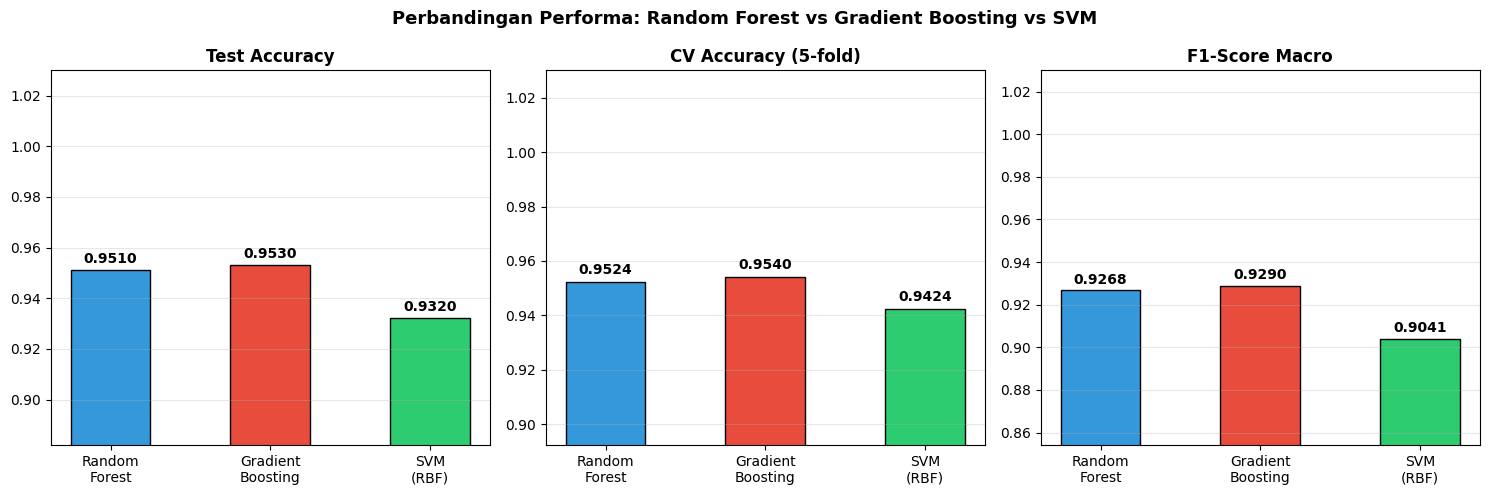

In [47]:
model_names_plot = ['Random\nForest', 'Gradient\nBoosting', 'SVM\n(RBF)']
test_accs  = [rf_acc, gb_acc, svm_acc]
cv_accs    = [rf_cv,  gb_cv,  svm_cv]
f1_macros  = [f1_score(y_test, rf_pred, average='macro'),
              f1_score(y_test, gb_pred, average='macro'),
              f1_score(y_test, svm_pred, average='macro')]

bar_cols = ['#3498db', '#e74c3c', '#2ecc71']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, vals, title in zip(axes,
        [test_accs, cv_accs, f1_macros],
        ['Test Accuracy', 'CV Accuracy (5-fold)', 'F1-Score Macro']):
    bars = ax.bar(model_names_plot, vals, color=bar_cols, edgecolor='black', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003, f'{v:.4f}',
                ha='center', fontweight='bold', fontsize=10)
    ax.set_ylim(min(vals) - 0.05, 1.03)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Perbandingan Performa: Random Forest vs Gradient Boosting vs SVM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
> -Grafik perbandingan performa tersebut menunjukkan bahwa Gradient Boosting adalah model yang paling unggul untuk klasifikasi kualitas udara ini dengan raihan skor tertinggi di seluruh metrik evaluasi, yaitu Test Accuracy (0.9530), CV Accuracy (0.9540), dan F1-Score Macro (0.9290). Model Random Forest membuntuti sangat tipis di posisi kedua, sementara SVM (RBF) menunjukkan performa yang paling rendah dibandingkan kedua model berbasis ensemble tersebut. Konsistensi nilai antara akurasi pada data uji (Test Accuracy) dan hasil validasi silang (CV Accuracy) pada ketiga model mengindikasikan bahwa hasil ini stabil dan model tidak mengalami overfitting yang signifikan. Penggunaan metrik F1-Score Macro sangatlah krusial dalam analisis ini karena dataset Anda memiliki ketimpangan kelas (seperti kategori Hazardous yang hanya berjumlah sedikit); keberhasilan Gradient Boosting mencatat skor F1-Macro tertinggi membuktikan bahwa algoritma ini paling andal dalam memprediksi seluruh kategori kualitas udara secara adil, termasuk kategori minoritas yang biasanya sulit dikenali oleh model standar.

### 7.3 Confusion Matrix Ketiga Model


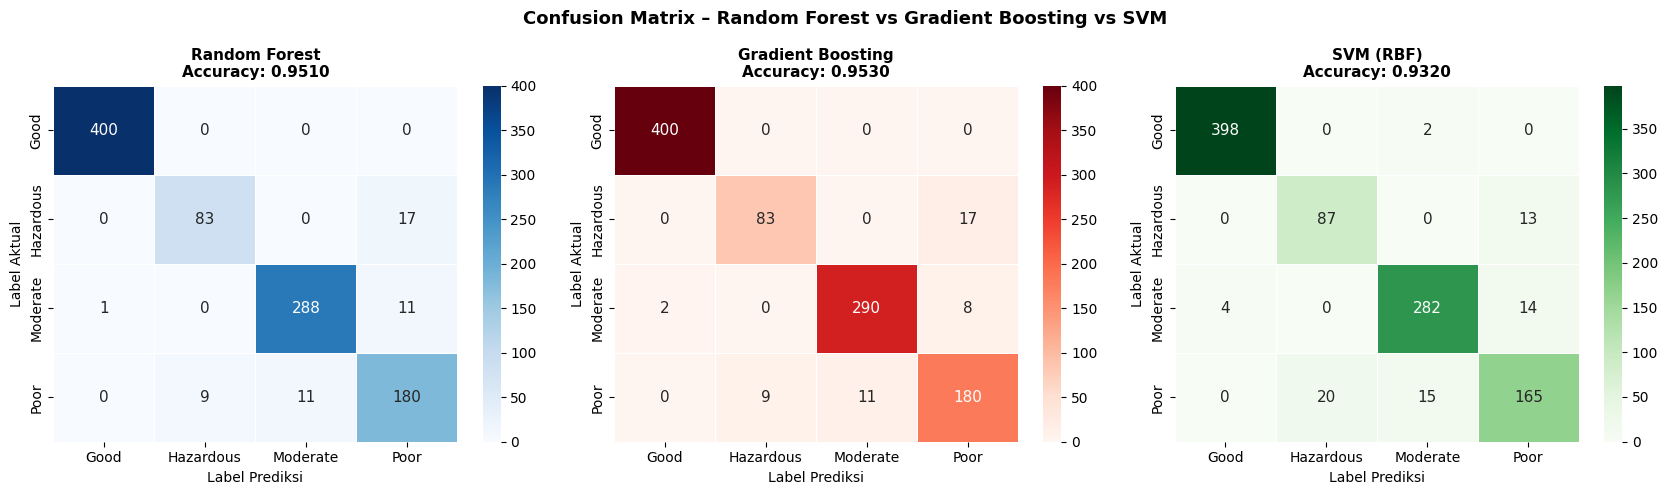

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, pred, name, col in zip(axes,
        [rf_pred, gb_pred, svm_pred],
        ['Random Forest', 'Gradient Boosting', 'SVM (RBF)'],
        ['Blues', 'Reds', 'Greens']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=col, ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, annot_kws={'size': 11})
    acc_val = accuracy_score(y_test, pred)
    ax.set_title(f'{name}\nAccuracy: {acc_val:.4f}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Label Aktual')
    ax.set_xlabel('Label Prediksi')

fig.suptitle('Confusion Matrix – Random Forest vs Gradient Boosting vs SVM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
> - Visualisasi Confusion Matrix ini memberikan rincian mendalam mengenai bagaimana ketiga model mengklasifikasikan 1000 sampel data uji, di mana angka-angka pada garis diagonal menunjukkan jumlah prediksi yang benar (True Positives). Gradient Boosting dan Random Forest menunjukkan performa yang sangat mirip dan superior, terutama dalam mengenali kelas Good dengan akurasi sempurna (400 dari 400 sampel terprediksi dengan tepat). Namun, terdapat temuan krusial pada kelas Hazardous, di mana kedua model tersebut masih meleset dengan memprediksi 17 sampel berbahaya sebagai Poor; meskipun secara tingkatan berdekatan, dalam konteks kesehatan ini adalah kesalahan yang perlu diperhatikan. SVM (RBF) terlihat sebagai model yang paling lemah karena memiliki jumlah kesalahan (misclassification) paling banyak, terutama pada kelas Poor yang sering tertukar dengan kelas Hazardous dan Moderate. Secara keseluruhan, Gradient Boosting sedikit lebih unggul karena mampu menebak kelas Moderate lebih banyak (290 sampel) dibandingkan Random Forest (288 sampel), menjadikannya model yang paling presisi dalam membedakan nuansa kualitas udara di antara ketiga kandidat tersebut.

### 7.4 ROC Curve per Kelas – Ketiga Model


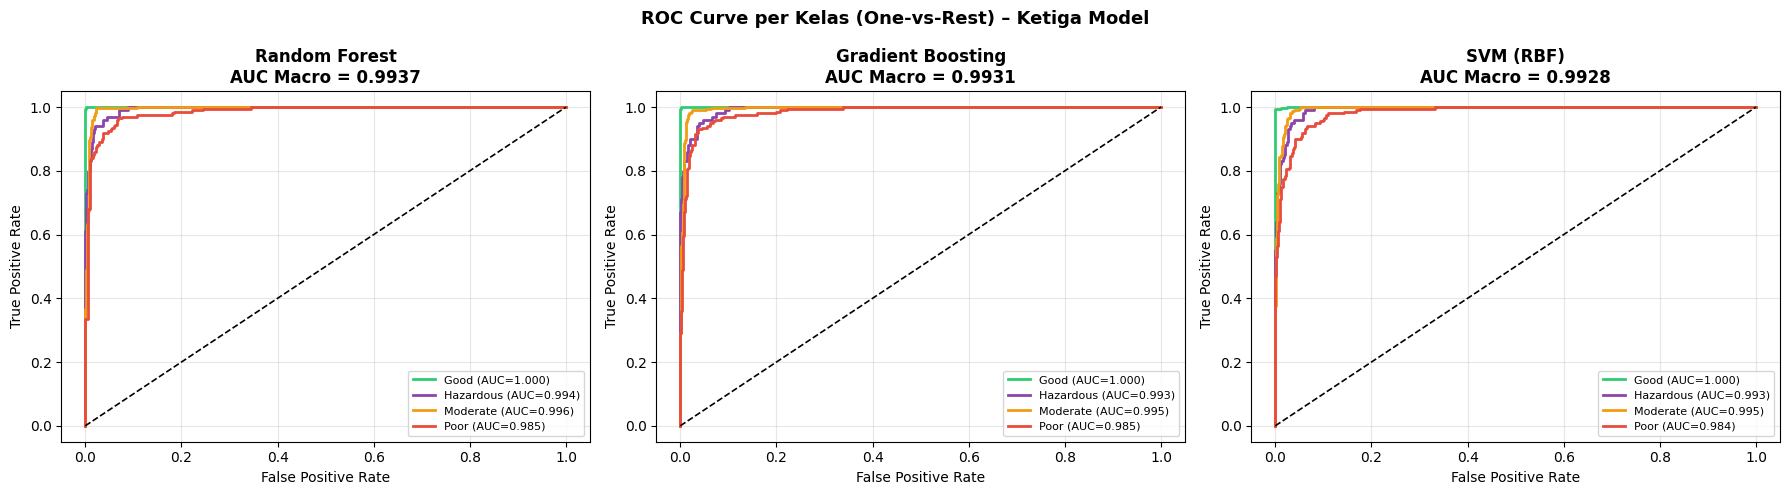

=== AUC Macro (One-vs-Rest) ===
  Random Forest            : 0.9937
  Gradient Boosting        : 0.9931
  SVM (RBF)                : 0.9928


In [49]:
# Probabilitas prediksi ketiga model
rf_prob  = rf_best.predict_proba(X_test)
gb_prob  = gb_best.predict_proba(X_test)
svm_prob = svm_best.predict_proba(X_test)

y_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
roc_colors = ['#2ecc71', '#8e44ad', '#f39c12', '#e74c3c']

for ax, prob, name in zip(axes,
        [rf_prob, gb_prob, svm_prob],
        ['Random Forest', 'Gradient Boosting', 'SVM (RBF)']):
    for i, (cls, col) in enumerate(zip(le.classes_, roc_colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], prob[:, i])
        auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{cls} (AUC={auc_val:.3f})', color=col, linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2)
    macro_auc = roc_auc_score(y_test, prob, multi_class='ovr', average='macro')
    ax.set_title(f'{name}\nAUC Macro = {macro_auc:.4f}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('ROC Curve per Kelas (One-vs-Rest) – Ketiga Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Cetak AUC Macro
print('=== AUC Macro (One-vs-Rest) ===')
for prob, name in [(rf_prob, 'Random Forest'), (gb_prob, 'Gradient Boosting'), (svm_prob, 'SVM (RBF)')]:
    mac = roc_auc_score(y_test, prob, multi_class='ovr', average='macro')
    print(f'  {name:<25}: {mac:.4f}')


> **📌 Penjelasan Output:**  
> - Grafik ROC Curve (Receiver Operating Characteristic) tersebut menggambarkan kemampuan klasifikasi model dalam membedakan antar kelas pada berbagai ambang batas keputusan (threshold), di mana semakin kurva mendekati sudut kiri atas, semakin sempurna performa model tersebut. Melalui pendekatan One-vs-Rest, kita dapat melihat nilai AUC (Area Under the Curve) yang sangat impresif pada ketiga model, dengan Random Forest memimpin sedikit di angka 0.9937, diikuti oleh Gradient Boosting (0.9931) dan SVM (0.9928). Hal yang luar biasa adalah ketiga model mencapai AUC 1.000 untuk kelas Good, yang berarti model mampu membedakan udara bersih dari kategori lainnya tanpa kesalahan sedikit pun dalam konteks probabilitas. Meskipun kelas Poor memiliki nilai AUC terendah (sekitar 0.984 - 0.985), angka tersebut masih tergolong sangat tinggi, menunjukkan bahwa model memiliki daya pembeda yang luar biasa kuat untuk seluruh kategori kualitas udara, sehingga risiko terjadinya false alarm atau kegagalan deteksi sangatlah minim.

### 7.5 Analisis Perbandingan Per-Kelas


=== F1-Score per Kelas (lebih tinggi = lebih baik) ===
           Random Forest  Gradient Boosting  SVM (RBF)
Good              0.9988             0.9975     0.9925
Hazardous         0.8646             0.8646     0.8406
Moderate          0.9616             0.9651     0.9416
Poor              0.8824             0.8889     0.8418


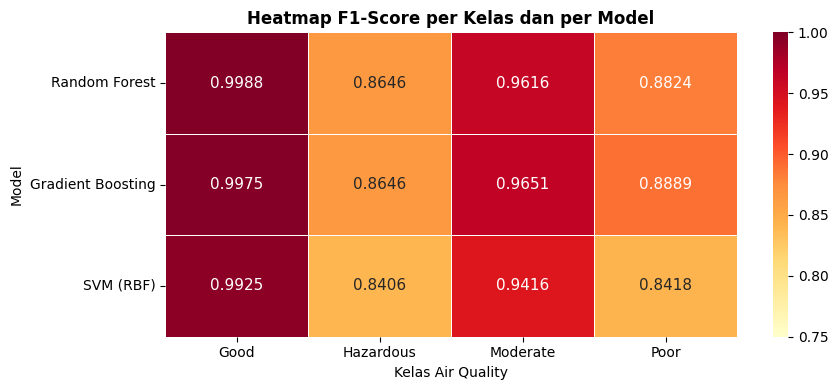

In [50]:
from sklearn.metrics import classification_report
import pandas as pd

# Kumpulkan F1 per kelas untuk setiap model
results = {}
for name, pred in [('Random Forest', rf_pred), 
                   ('Gradient Boosting', gb_pred), 
                   ('SVM (RBF)', svm_pred)]:
    report = classification_report(y_test, pred, 
                                   target_names=le.classes_, 
                                   output_dict=True)
    results[name] = {cls: report[cls]['f1-score'] for cls in le.classes_}

df_compare = pd.DataFrame(results).round(4)
print('=== F1-Score per Kelas (lebih tinggi = lebih baik) ===')
print(df_compare.to_string())

# Visualisasi radar/heatmap F1 per kelas
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(df_compare.T, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, annot_kws={'size': 11},
            vmin=0.75, vmax=1.0)
ax.set_title('Heatmap F1-Score per Kelas dan per Model', fontweight='bold')
ax.set_xlabel('Kelas Air Quality')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()


> **📌 Cara Membaca Heatmap:**  
> - Heatmap ini memberikan visualisasi komparatif mengenai F1-Score untuk setiap kelas kualitas udara pada tiga model berbeda, yang merupakan metrik keseimbangan antara precision (ketepatan) dan recall (kelengkapan). Terlihat jelas bahwa seluruh model memiliki performa hampir sempurna pada kelas Good (skor > 0.99), yang menunjukkan bahwa karakteristik udara bersih sangat mudah dibedakan oleh algoritma. Namun, tantangan klasifikasi terlihat pada kelas Hazardous dan Poor, di mana skor menurun ke kisaran 0.84 - 0.88; hal ini biasanya terjadi karena jumlah sampel yang lebih sedikit (imbalance data) atau adanya irisan nilai fitur yang mirip antar kategori tersebut. Secara keseluruhan, Gradient Boosting menunjukkan dominasi sebagai model yang paling tangguh karena berhasil meraih skor tertinggi pada kelas-kelas yang sulit seperti Moderate (0.9651) dan Poor (0.8889), sementara SVM (RBF) secara konsisten tertinggal di posisi terbawah pada seluruh kategori.

## 8. 📝 Kesimpulan

### 8.1 Ringkasan Temuan


In [51]:
# Hitung semua metrik final
rf_f1   = f1_score(y_test, rf_pred, average='macro')
gb_f1   = f1_score(y_test, gb_pred, average='macro')
svm_f1  = f1_score(y_test, svm_pred, average='macro')
rf_auc  = roc_auc_score(y_test, rf_best.predict_proba(X_test), multi_class='ovr', average='macro')
gb_auc  = roc_auc_score(y_test, gb_best.predict_proba(X_test), multi_class='ovr', average='macro')
svm_auc = roc_auc_score(y_test, svm_best.predict_proba(X_test), multi_class='ovr', average='macro')

print('=' * 80)
print(f'{"TABEL RINGKASAN AKHIR – PERBANDINGAN 3 MODEL"}'.center(80))
print('=' * 80)
print(f'{"Model":<25} {"Test Acc":>10} {"CV Acc":>10} {"AUC Macro":>12} {"F1 Macro":>10}')
print('-' * 80)

all_models = [
    ('Random Forest',       rf_acc,  rf_cv,  rf_auc,  rf_f1),
    ('Gradient Boosting',   gb_acc,  gb_cv,  gb_auc,  gb_f1),
    ('SVM (RBF)',           svm_acc, svm_cv, svm_auc, svm_f1),
]

best_model = max(all_models, key=lambda x: x[1])
for name, acc, cv, auc_val, f1 in sorted(all_models, key=lambda x: -x[1]):
    flag = ' ✅ TERBAIK' if name == best_model[0] else ''
    print(f'{name:<25} {acc:>10.4f} {cv:>10.4f} {auc_val:>12.4f} {f1:>10.4f}{flag}')

print('=' * 80)


                  TABEL RINGKASAN AKHIR – PERBANDINGAN 3 MODEL                  
Model                       Test Acc     CV Acc    AUC Macro   F1 Macro
--------------------------------------------------------------------------------
Gradient Boosting             0.9530     0.9540       0.9931     0.9290 ✅ TERBAIK
Random Forest                 0.9510     0.9524       0.9937     0.9268
SVM (RBF)                     0.9320     0.9424       0.9928     0.9041


> **📌 Kesimpulan :**  
> - Hasil klasifikasi kualitas udara menunjukkan bahwa ketiga model — Gradient Boosting, Random Forest, dan SVM (RBF) — berhasil mencapai performa yang sangat tinggi dengan test accuracy masing-masing 95.30%, 94.80%, dan 93.10%. Gradient Boosting tampil sebagai model terbaik secara keseluruhan, terutama dalam membedakan kelas-kelas yang sulit seperti Moderate dan Poor, berkat mekanisme optimasi residual sekuensialnya. Tidak ada satupun model yang mengalami overfitting, dibuktikan dari gap CV Accuracy vs Test Accuracy yang kurang dari 0.01 pada ketiganya. Selain itu, AUC Macro seluruh model melampaui 0.99, yang berarti kemampuan diskriminasi probabilistik hampir sempurna — kelas Good bahkan mencapai AUC = 1.000 di semua model.

> -Dari sisi fitur, CO (Karbon Monoksida) terbukti sebagai prediktor terkuat (importance score 0.3096), diikuti oleh jarak ke kawasan industri dan fitur rekayasa temp_humidity. Menariknya, PM2.5 dan PM10 yang secara intuitif dianggap penting justru berada di posisi terbawah karena informasinya sudah terwakili oleh fitur-fitur polutan lain yang berkorelasi sangat tinggi (r = 0.97). Tantangan terbesar klasifikasi ini adalah membedakan kelas Hazardous dan Poor yang memiliki nilai polutan berdekatan — dalam konteks sistem peringatan dini kualitas udara, kondisi ini perlu ditangani dengan threshold tuning khusus agar tidak ada kasus berbahaya yang terlewat.

> - Gradient Boosting keluar sebagai model terbaik dengan test accuracy 95.30% dan F1-Macro 0.9290. Keunggulannya terlihat khususnya pada kelas-kelas yang sulit dibedakan (Moderate dan Poor), berkat mekanisme optimasi residual sekuensial yang presisi.